In [1]:
# Add the parent directory of the current working directory to the Python path at runtime. 
# In order to import modules from the src directory.
import os
import sys 

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

In [2]:
import tomllib

import numpy as np
import matplotlib.pyplot as plt

from src.sim_utils import generate_time_index, generate_condition_space
from src.anl_utils import order_parameter
from src.stimulus_generator import StimulusGenerator
from src.v1_model import V1Model

from copy import deepcopy

In [3]:
def load_configurations():
    """
    Load the model, stimulus, simulation, and experiment parameters.

    Returns
    -------
    model_parameters : dict
        The model parameters.
    stimulus_parameters : dict
        The stimulus parameters.
    simulation_parameters : dict
        The simulation parameters.
    experiment_parameters : dict
        The experiment parameters.
    """
    parameters = {}
    config_files = ['model', 'stimulus', 'simulation']

    for config_file in config_files:
        with open(f'../config/simulation/{config_file}.toml', 'rb') as f:
            parameters[config_file] = tomllib.load(f)

    with open('../config/analysis/experiment_actual.toml', 'rb') as f:
        parameters['experiment'] = tomllib.load(f)

    return parameters['model'], parameters['stimulus'], parameters[
        'simulation'], parameters['experiment']



def stimulus_construction(stimulus_parameters_original, scaling_factor, contrast_range, mean_contrast=0.5):
    """
    Construct the stimulus.

    Parameters
    ----------
    stimulus_parameters : dict
        The stimulus parameters.
    scaling_factor : float
        The scaling factor for the stimulus.
    mean_contrast : float
        The mean contrast of the stimulus.

    Returns
    -------
    stimulus : np.ndarray
        The constructed stimulus.
    """

    stimulus_parameters = deepcopy(stimulus_parameters_original)

    # reduce stimulus resolution to include background without running out of memory
    stimulus_parameters['stimulus_resolution'] = stimulus_parameters['stimulus_resolution'] // 2
    stimulus_parameters['annulus_resolution'] = stimulus_parameters['annulus_resolution'] // 2
    stimulus_parameters['stimulus_num_pixels'] = stimulus_parameters['stimulus_resolution']**2

    # initialize figure generator
    figure_generator = StimulusGenerator(stimulus_parameters)

    # adjust stimulus parameters to include background region
    stimulus_parameters['stimulus_side_length'] = stimulus_parameters['stimulus_side_length'] * 1.5
    stimulus_parameters['stimulus_resolution'] = int(stimulus_parameters['stimulus_resolution'] * 3)
    stimulus_parameters['stimulus_num_pixels'] = stimulus_parameters['stimulus_resolution'] ** 2

    # initialize background generator
    background_generator = StimulusGenerator(stimulus_parameters)

    # create figure and background
    figure = figure_generator.generate(scaling_factor, contrast_range, mean_contrast)
    stimulus = background_generator.generate(scaling_factor, 1, mean_contrast)

    # embed figure in center of background
    center = stimulus_parameters['stimulus_resolution'] // 2
    size = figure.shape[0]
    half_size_floor = size // 2
    half_size_ceil = size - half_size_floor

    

    stimulus[
        center - half_size_floor:center + half_size_ceil,
        center - half_size_floor:center + half_size_ceil
    ] = figure


    return stimulus, stimulus_parameters


def run_experiment(stimulus_parameters, model_parameters, simulation_parameters, experiment_parameters, num_blocks = 5):
    """
    Run the V1 model experiment.

    Parameters
    ----------
    stimulus_parameters : dict
        The stimulus parameters.
    model_parameters : dict
        The model parameters.
    simulation_parameters : dict
        The simulation parameters.
    experiment_parameters : dict
        The experiment parameters.
    num_blocks : int
        The number of blocks to run.

    Returns
    -------
    figure_sync : np.ndarray
        The synchronization values for the figure region.
    background_sync : np.ndarray
        The synchronization values for the background region.
    """

    # create a copy of the original stimulus parameters
    stimulus_parameters_original = deepcopy(stimulus_parameters)

    # generate time index
    sync_index, _ = generate_time_index(simulation_parameters)

    # generate condition space
    grid_coarseness, contrast_heterogeneity = generate_condition_space(
    experiment_parameters)

    # initialize Arnold tongues
    figure_sync = np.zeros((experiment_parameters['num_grid_coarseness'],
                              experiment_parameters['num_contrast_heterogeneity'], num_blocks))
    background_sync = np.zeros((experiment_parameters['num_grid_coarseness'],
                                 experiment_parameters['num_contrast_heterogeneity'], num_blocks))

    resolution = model_parameters['num_populations']**0.5
    center = int(resolution // 2)
    half_size = int(resolution // 4)

    all_regions = np.arange(0, int(resolution))

    figure_region = (np.arange(center - half_size, center + half_size),
                     np.arange(center - half_size, center + half_size))
    # background_region is all regions excluding figure region
    background_region = (np.setdiff1d(all_regions, figure_region[0]),
                         np.setdiff1d(all_regions, figure_region[1]))

    num_figure = len(figure_region[0]) * len(figure_region[1])
    num_background = len(background_region[0]) * len(background_region[1])

    for b in range(num_blocks):
        for i, gc in enumerate(grid_coarseness):
            for j, ch in enumerate(contrast_heterogeneity):

                # construct stimulus
                stimulus, stimulus_parameters = stimulus_construction(stimulus_parameters_original, gc, ch)

                # initialize model
                model = V1Model(model_parameters, stimulus_parameters)
                model.compute_omega(stimulus.flatten())

                print(ch)
                print(model.omega.reshape(40,40)[figure_region[0],figure_region[1]].var())
                print(model.omega.reshape(40,40)[background_region[0],background_region[1]].var())

                # run simulation
                state, _ = model.simulate(simulation_parameters)

                # compute order parameter for figure and background regions
                figure = state.reshape(-1, 40, 40)[:,figure_region[0],figure_region[1]].reshape(-1,num_figure)
                background = state.reshape(-1, 40, 40)[:,background_region[0],background_region[1]].reshape(-1,num_background)

                # compute synchronization for figure and background regions
                synchronization = np.abs(order_parameter(figure))
                figure_sync[i,j,b] = np.mean(synchronization[sync_index])

                synchronization = np.abs(order_parameter(background))
                background_sync[i,j,b] = np.mean(synchronization[sync_index])

    return figure_sync, background_sync




In [4]:
model_parameters, stimulus_parameters, simulation_parameters, experiment_parameters = load_configurations()

# adjust experiment parameters to include more conditions
experiment_parameters['num_grid_coarseness'] = 10
experiment_parameters['num_contrast_heterogeneity'] = 10
experiment_parameters['num_conditions'] = experiment_parameters['num_grid_coarseness'] * experiment_parameters['num_contrast_heterogeneity']

# add num_time_steps
simulation_parameters['num_time_steps'] = int(
        simulation_parameters['simulation_time'] /
        simulation_parameters['time_step'])

# increase number of populations to accommodate larger stimulus
model_parameters['num_populations'] = 40**2

In [5]:
figure_sync, background_sync = run_experiment(stimulus_parameters, model_parameters, simulation_parameters, experiment_parameters)

0.01
20.711181032104754
107.92609569272318


/home/mario/miniconda3/envs/bat_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mario/miniconda3/envs/bat_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


0.12
4.648763067070436
89.43596737006018
0.23
19.354276727827557
42.27221766071777


KeyboardInterrupt: 

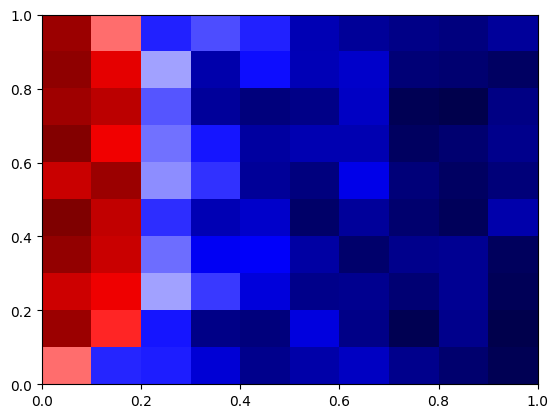

In [ ]:
plt.imshow(figure_sync.mean(axis=2), extent=(0,1,0,1), aspect='auto', cmap='seismic')

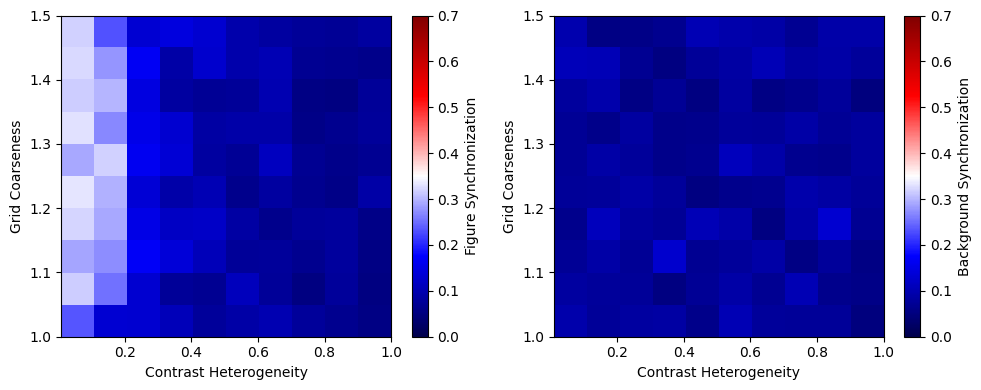

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(figure_sync.mean(axis=2), aspect='auto', cmap='seismic', vmin=0, vmax=.7,
           extent=[experiment_parameters['min_contrast_heterogeneity'],
                   experiment_parameters['max_contrast_heterogeneity'],
                   experiment_parameters['min_grid_coarseness'],
                   experiment_parameters['max_grid_coarseness']])
plt.colorbar(label='Figure Synchronization')
plt.xlabel('Contrast Heterogeneity')
plt.ylabel('Grid Coarseness')
plt.subplot(1, 2, 2)
plt.imshow(background_sync.mean(axis=2), aspect='auto', cmap='seismic', vmin=0, vmax=.7,
           extent=[experiment_parameters['min_contrast_heterogeneity'],
                   experiment_parameters['max_contrast_heterogeneity'],
                   experiment_parameters['min_grid_coarseness'],
                   experiment_parameters['max_grid_coarseness']])
plt.colorbar(label='Background Synchronization')
plt.xlabel('Contrast Heterogeneity')
plt.ylabel('Grid Coarseness')
plt.tight_layout()
plt.show()